# Ejercicio 1 : MLP en Keras sobre Iris: 4×3×3 vs 4×3×3×3×3

Misma configuración en las dos corridas: sigmoide en todas las capas, `MeanSquaredError`, `SGD(learning_rate=0.03)`, **500 épocas** (batch por defecto = 32).


In [1]:
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

tf.keras.utils.set_random_seed(42)

In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0] / 1 => [0 1 0] / 2 => [0 0 1]
print(X[0], target[0], Y[0])

[5.1 3.5 1.4 0.2] 0 [1 0 0]


## Corrida A — red original 4×3×3

In [3]:
model_A = keras.Sequential(
    [
        layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),  # oculta
        layers.Dense(3, activation="sigmoid", name="layer2"),                    # salida
    ]
)
model_A.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

A (4x3x3)  loss final = 0.1509 | exactitud = 66.67% | tiempo = 22.2s
loss cada 50 épocas: [0.3006, 0.2394, 0.2142, 0.2016, 0.1922, 0.1841, 0.1763, 0.169, 0.1623, 0.1562]


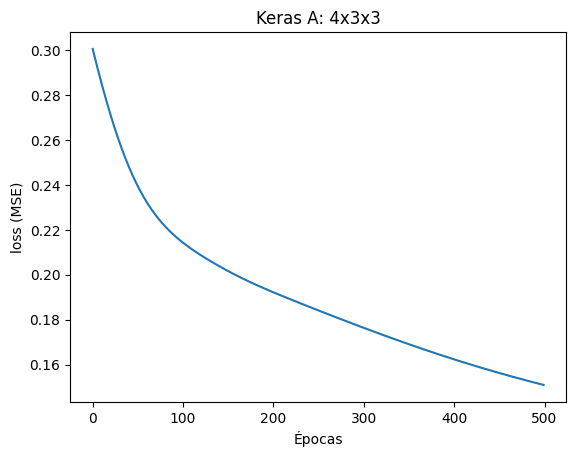

predict([3,3,1,1]) = [[0.5178732  0.28180325 0.19554119]]


In [4]:
model_A.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.03),
                loss=tf.keras.losses.MeanSquaredError())
t0 = time.time()
history_A = model_A.fit(X, Y, epochs=500, verbose=0)
time_A = time.time() - t0

pred_A = np.argmax(model_A.predict(X, verbose=0), axis=1)
acc_A = np.mean(pred_A == target)
print(f"A (4x3x3)  loss final = {history_A.history['loss'][-1]:.4f} | exactitud = {acc_A:.2%} | tiempo = {time_A:.1f}s")
print("loss cada 50 épocas:", [round(history_A.history['loss'][i], 4) for i in range(0, 500, 50)])

plt.plot(history_A.history["loss"]); plt.xlabel("Épocas"); plt.ylabel("loss (MSE)"); plt.title("Keras A: 4x3x3"); plt.show()
print("predict([3,3,1,1]) =", model_A.predict(np.array([[3,3,1,1]]), verbose=0))

## Corrida B — red profunda 4×3×3×3×3
Se añaden dos `Dense(3, sigmoid)` **antes** de la capa de salida. `model.summary()` debe mostrar **4** capas `Dense`.

In [6]:
tf.keras.utils.set_random_seed(42)
model_B = keras.Sequential(
    [
        layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
        layers.Dense(3, activation="sigmoid", name="layer2"),   # oculta +1
        layers.Dense(3, activation="sigmoid", name="layer3"),   # oculta +2
        layers.Dense(3, activation="sigmoid", name="layer4"),   # salida
    ]
)
model_B.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

B (4x3x3x3x3)  loss final = 0.2217 | exactitud = 50.00% | tiempo = 20.5s
loss cada 50 épocas: [0.3097, 0.2555, 0.2348, 0.2272, 0.2242, 0.2229, 0.2223, 0.222, 0.2219, 0.2218]


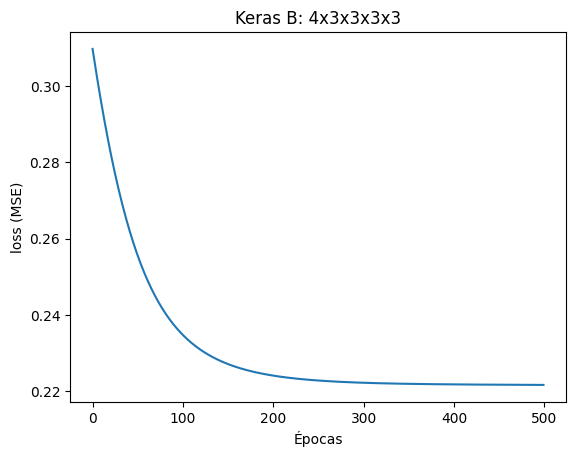

predict([3,3,1,1]) = [[0.34232172 0.33883744 0.33637056]]


In [7]:
model_B.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.03),
                loss=tf.keras.losses.MeanSquaredError())
t0 = time.time()
history_B = model_B.fit(X, Y, epochs=500, verbose=0)
time_B = time.time() - t0

pred_B = np.argmax(model_B.predict(X, verbose=0), axis=1)
acc_B = np.mean(pred_B == target)
print(f"B (4x3x3x3x3)  loss final = {history_B.history['loss'][-1]:.4f} | exactitud = {acc_B:.2%} | tiempo = {time_B:.1f}s")
print("loss cada 50 épocas:", [round(history_B.history['loss'][i], 4) for i in range(0, 500, 50)])

plt.plot(history_B.history["loss"]); plt.xlabel("Épocas"); plt.ylabel("loss (MSE)"); plt.title("Keras B: 4x3x3x3x3"); plt.show()
print("predict([3,3,1,1]) =", model_B.predict(np.array([[3,3,1,1]]), verbose=0))

## Comparación A vs B

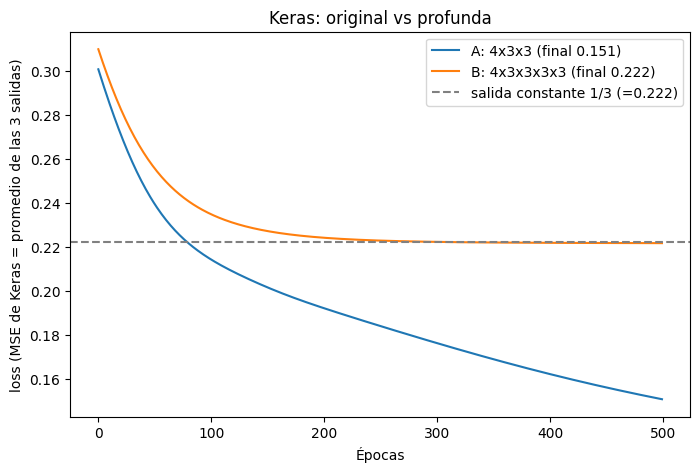

                 loss final  exactitud  tiempo (s)
A 4x3x3              0.1509     66.67%        22.2
B 4x3x3x3x3          0.2217     50.00%        20.5

Para comparar con NumPy: error_numpy / 3 = loss de Keras (Keras promedia las 3 salidas).


In [8]:
plt.figure(figsize=(8,5))
plt.plot(history_A.history["loss"], label=f"A: 4x3x3 (final {history_A.history['loss'][-1]:.3f})")
plt.plot(history_B.history["loss"], label=f"B: 4x3x3x3x3 (final {history_B.history['loss'][-1]:.3f})")
plt.axhline(2/9, color="gray", ls="--", label="salida constante 1/3 (=0.222)")
plt.xlabel("Épocas"); plt.ylabel("loss (MSE de Keras = promedio de las 3 salidas)")
plt.legend(); plt.title("Keras: original vs profunda"); plt.show()

print(f"{'':16}{'loss final':>11}{'exactitud':>11}{'tiempo (s)':>12}")
print(f"{'A 4x3x3':16}{history_A.history['loss'][-1]:11.4f}{acc_A:11.2%}{time_A:12.1f}")
print(f"{'B 4x3x3x3x3':16}{history_B.history['loss'][-1]:11.4f}{acc_B:11.2%}{time_B:12.1f}")
print("\nPara comparar con NumPy: error_numpy / 3 = loss de Keras (Keras promedia las 3 salidas).")

## Notas para el reporte
- Keras usa **mini-batch de 32** (5 actualizaciones por época) y **baraja** los datos; el notebook NumPy hace 150 actualizaciones por época sin barajar. Por eso las curvas no coinciden aunque la topología sea la misma.
- Inicialización: Keras usa Glorot uniforme con sesgos en 0; el NumPy usa U(-0.5, 0.5).
- Una loss ≈ 0.222 equivale a emitir ≈ 1/3 en las 3 salidas.
- Cambia **una sola cosa a la vez** si haces el reto (ReLU+softmax, más neuronas).